In [1]:
# auto reload
%load_ext autoreload
%autoreload 2


In [2]:
import torch
import scipy.io as sio
import numpy as np
import os
import skimage.io
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

**Download model**

In [3]:
import torchvision.transforms as transforms
import skimage.transform
from dataloader import demosaic_raw,DatasetFromFilenames,get_paths

In [4]:
import matplotlib.pyplot as plt
from SRIL_utils.plot_aux import myim 
 

In [6]:
import argparse

In [7]:
parser = argparse.ArgumentParser()
#model and data locs
parser.add_argument('--train_meas_filenames', default='filenames/train_meas_ilsvrc_flatcam.txt')
parser.add_argument('--val_meas_filenames', default='filenames/val_meas_ilsvrc_flatcam_smaller.txt')
parser.add_argument('--train_orig_filenames', default='filenames/train_orig_ilsvrc_flatcam.txt')
parser.add_argument('--val_orig_filenames', default='filenames/val_orig_ilsvrc_flatcam_smaller.txt')
parser.add_argument('--architecture',default='UNET')
parser.add_argument('--modelRoot', default='flatnet_new')
parser.add_argument('--checkpoint', default='')
#lossweightage and gradientweightage
parser.add_argument('--wtp', default=1.2, type=float)
parser.add_argument('--wtmse', default=1, type=float)
parser.add_argument('--wta', default=0.6, type=float)
parser.add_argument('--generatorLR', default=1e-4, type=float)
parser.add_argument('--discriminatorLR', default=1e-4, type=float)
parser.add_argument('--init', default='Transpose')
parser.add_argument('--numEpoch', default=20,type=int)
parser.add_argument('--disPreEpochs', default=5,type=int)
parser.add_argument('--valFreq', default=200,type=int)
parser.add_argument('--pretrain',dest='pretrain', action='store_true')
parser.set_defaults(pretrain=True)

#opt = parser.parse_args()

In [8]:
opt = parser.parse_args(args=[])

In [9]:
 opt.init

'Transpose'

In [10]:
d=sio.loadmat('data/flatcam_prototype2_calibdata.mat')
phil=np.zeros((500,256,1))
phir=np.zeros((620,256,1))
phil[:,:,0]=d['P1gb']
phir[:,:,0]=d['Q1gb']
phil=phil.astype('float32')
phir=phir.astype('float32')

In [11]:
phil.shape,phir.shape

((500, 256, 1), (620, 256, 1))

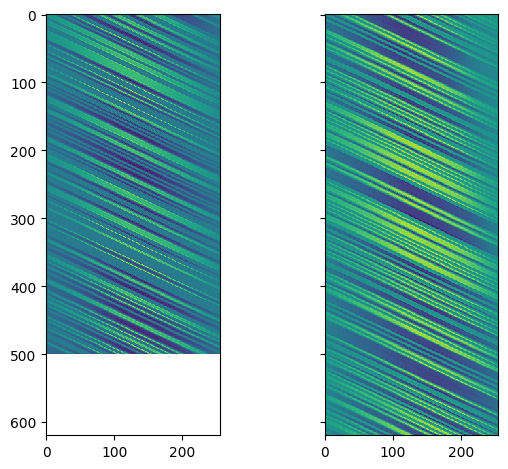

[(<Axes: >, None), (<Axes: >, None)]

In [13]:
myim(phil,phir)

In [19]:
train_meas_filenames = r"/mnt/c/dev/lensless/Dataset/Display Captures/Filenames/train_measurement_ilsvrc_flatcam.txt"
train_orig_filenames = r"/mnt/c/dev/lensless/Dataset/Display Captures/Filenames/train_groundtruth_ilsvrc_flatcam.txt"
data_root_meas = r'/mnt/c/dev/lensless/Dataset/Display Captures/ILSVRC2012_Measurement/'
data_root_orig = r'/mnt/c/dev/lensless/Dataset/Display Captures/ILSVRC_Groundtruth/'


In [20]:
opt.train_meas_filenames

'filenames/train_meas_ilsvrc_flatcam.txt'

In [21]:
params_train = {'batch_size': 4,
		  'shuffle': True,
		  'num_workers': 0}

In [30]:
ds_tarin = DatasetFromFilenames(
        train_meas_filenames,
        train_orig_filenames,
        data_root_meas=data_root_meas,
        data_root_orig=data_root_orig,
        )

In [17]:
train_loader = torch.utils.data.DataLoader(
    ds_tarin,
     **params_train
     )


In [31]:
x,y= ds_tarin[0]

In [28]:
x.shape , y.shape

(torch.Size([4, 500, 620]), torch.Size([3, 256, 256]))

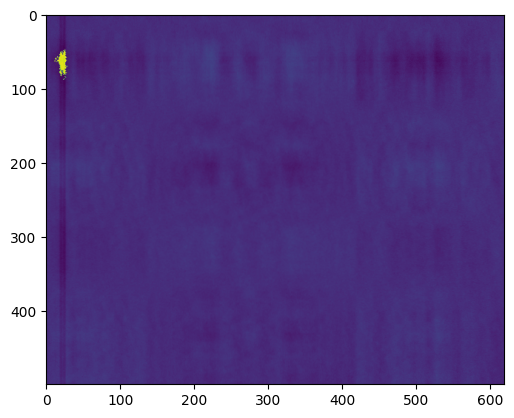

In [37]:
plt.imshow(x[3])

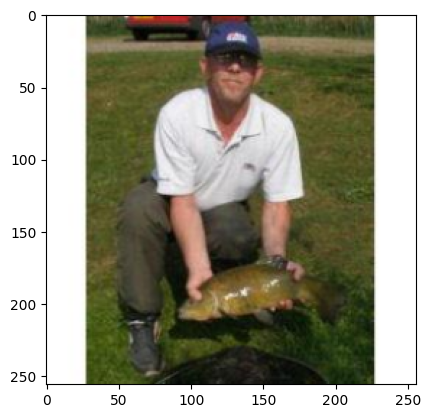

In [32]:
plt.imshow(ds_tarin.to_numpy(y))

In [3]:
!wget -q -O flatnet_separable_pointGrey_transposeInit https://www.dropbox.com/s/zh8ucresezrfb5o/flatnet_separable_pointGrey_transposeInit?dl=0
!wget -q -O flatnet_separable_pointGrey_randomInit https://www.dropbox.com/s/kve8ki2wll9lytg/flatnet_separable_pointGrey_randomInit?dl=0

**Set the path to the trained model**

In [4]:
# specify the path to the pretrained model.
# modelRoot = r'flatnet_separable_pointGrey_transposeInit' ##Use this for Proposed-T
modelRoot = r'flatnet_separable_pointGrey_randomInit' ##Use this for Proposed-R

In [5]:
from skimage import transform
tform = transform.SimilarityTransform(rotation=0.00174) #to account for small rotation 

In [6]:
class double_conv(nn.Module):
    '''(conv => BN => ReLU) * 2'''
    def __init__(self, in_ch, out_ch):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch,momentum=0.99),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch,momentum=0.99),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv(x)
        return x

    
    
class double_conv2(nn.Module):
    '''(conv => BN => ReLU) * 2'''
    def __init__(self, in_ch, out_ch):
        super(double_conv2, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3,stride=2, padding=1),
            nn.BatchNorm2d(out_ch,momentum=0.99),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch,momentum=0.99),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv(x)
        return x    

    
    

class inconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(inconv, self).__init__()
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(x)
        return x


class down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(down, self).__init__()
        self.mpconv = nn.Sequential(
            double_conv2(in_ch, out_ch)
        )

    def forward(self, x):
        x = self.mpconv(x)
        return x


class up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=False):
        super(up, self).__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, 2, stride=2)

        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffX = x1.size()[2] - x2.size()[2]
        diffY = x1.size()[3] - x2.size()[3]
        x2 = F.pad(x2, (diffX // 2, int(diffX / 2),
                        diffY // 2, int(diffY / 2)))
        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class outconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(outconv, self).__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3,padding=1)

    def forward(self, x):
        x = self.conv(x)
        return x

In [7]:
class FlatNet(nn.Module):
    def __init__(self, n_channels=4):
        super(FlatNet, self).__init__()
        self.inc = inconv(n_channels, 128)
        self.down1 = down(128, 256)
        self.down2 = down(256, 512)
        self.down3 = down(512, 1024)
        self.down4 = down(1024, 1024)
        self.up1 = up(2048, 512)
        self.up2 = up(1024, 256)
        self.up3 = up(512, 128)
        self.up4 = up(256, 128)
        self.outc = outconv(128, 3)
        self.PhiL =nn.Parameter(torch.randn(500,256,1)) 
        self.PhiR = nn.Parameter(torch.randn(620,256,1)) 
        self.bn=nn.BatchNorm2d(4,momentum=0.99)
    def forward(self, Xinp):
        
        X0 = F.leaky_relu(torch.matmul(torch.matmul(Xinp[:,0,:,:],self.PhiR[:,:,0]).permute(0,2,1),self.PhiL[:,:,0]).permute(0,2,1).unsqueeze(3))
        X11 = F.leaky_relu(torch.matmul(torch.matmul(Xinp[:,1,:,:],self.PhiR[:,:,0]).permute(0,2,1),self.PhiL[:,:,0]).permute(0,2,1).unsqueeze(3))
        X12 = F.leaky_relu(torch.matmul(torch.matmul(Xinp[:,2,:,:],self.PhiR[:,:,0]).permute(0,2,1),self.PhiL[:,:,0]).permute(0,2,1).unsqueeze(3))
        X2 = F.leaky_relu(torch.matmul(torch.matmul(Xinp[:,3,:,:],self.PhiR[:,:,0]).permute(0,2,1),self.PhiL[:,:,0]).permute(0,2,1).unsqueeze(3))
        Xout = torch.cat((X2,X12,X11,X0),3)
        x = Xout.permute(0,3,1,2)
        x = self.bn(x)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        x = self.outc(x)

            
        return torch.sigmoid(x)



**Load the model and update it state dictionary with the trained state dictionary**

In [8]:
flatnet = FlatNet(4)
flatnet.load_state_dict(torch.load(modelRoot,map_location=torch.device('cpu')))
flatnet.eval()

FlatNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.99, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.99, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): double_conv2(
        (conv): Sequential(
          (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (1): BatchNorm2d(256, eps=1e-05, momentum=0.99, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(256, eps=1e-05, momentum=0.99, affine=True, track_running_stats=True)
 

**Function to pre-process the measurement and evaluate it**

In [17]:
def preprocess(X):
    X=X/65535.0
    X_train=np.zeros((1,4,500,620))
    im1=np.zeros((512,640,4))
    im1[:,:,0]=X[0::2, 0::2]#b
    im1[:,:,1]=X[0::2, 1::2]#gb
    im1[:,:,2]=X[1::2, 0::2]#gr
    im1[:,:,3]=X[1::2, 1::2]#r
    im1=transform.warp(im1,tform)
    im=im1[6:506,10:630,:]      
    # rowMeans = im.mean(axis=1, keepdims=True)
    # colMeans = im.mean(axis=0, keepdims=True)
    # allMean = rowMeans.mean()
    # im = im - rowMeans - colMeans + allMean

    # X_train[0,:,:,:]=np.swapaxes(np.swapaxes(im,0,2),1,2)
    # X_train=X_train.astype('float32')
    # X_val=torch.from_numpy(X_train)
    # Xvalout=flatnet(X_val)
    # ims=Xvalout.detach().numpy()
    # ims=np.swapaxes(np.swapaxes(ims[0,:,:,:],0,2),0,1)
    # ims=(ims-np.min(ims))/(np.max(ims)-np.min(ims))
    return im


In [ ]:
def evaluate(X):
    X=X/65535.0
    X_train=np.zeros((1,4,500,620))
    im1=np.zeros((512,640,4))
    im1[:,:,0]=X[0::2, 0::2]#b
    im1[:,:,1]=X[0::2, 1::2]#gb
    im1[:,:,2]=X[1::2, 0::2]#gr
    im1[:,:,3]=X[1::2, 1::2]#r
    im1=transform.warp(im1,tform)
    im=im1[6:506,10:630,:]      
    rowMeans = im.mean(axis=1, keepdims=True)
    colMeans = im.mean(axis=0, keepdims=True)
    allMean = rowMeans.mean()
    im = im - rowMeans - colMeans + allMean

    X_train[0,:,:,:]=np.swapaxes(np.swapaxes(im,0,2),1,2)
    X_train=X_train.astype('float32')
    X_val=torch.from_numpy(X_train)
    Xvalout=flatnet(X_val)
    ims=Xvalout.detach().numpy()
    ims=np.swapaxes(np.swapaxes(ims[0,:,:,:],0,2),0,1)
    ims=(ims-np.min(ims))/(np.max(ims)-np.min(ims))
    return ims


**Load the measurement and evaluate it on the trained model**

In [12]:
X = skimage.io.imread("https://raw.githubusercontent.com/siddiquesalman/flatnet/flatnet-sep/example_data/fc_8.png") ## Specify the path to the measurement


In [20]:
im = preprocess(X)
im.shape

(500, 620, 4)

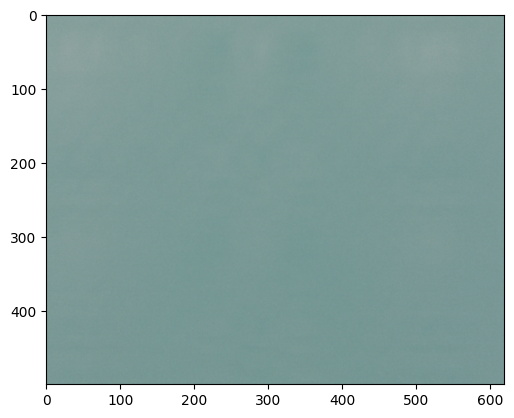

In [19]:
plt.imshow(im)

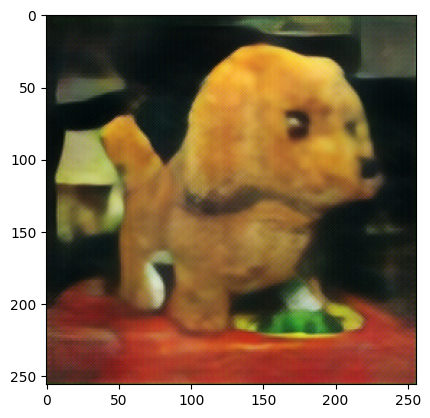

In [16]:
# Uncomment the below line if using local jupyter server
# !wget -q -O fc_8.png https://raw.githubusercontent.com/siddiquesalman/flatnet/flatnet-sep/example_data/fc_8.png
# Replace the input path with `fc_8.png`

#X = skimage.io.imread("https://raw.githubusercontent.com/siddiquesalman/flatnet/flatnet-sep/example_data/fc_8.png") ## Specify the path to the measurement
recn = evaluate(X)
plt.imshow(recn)
    